In [1]:
import pandas as pd


In [2]:
# Load the wheat dataset
X = pd.read_csv("wheat.data", index_col='id')
X.head()


,area,perimeter,compactness,length,width,asymmetry,groove,wheat_type
id,,,,,,,,
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,kama


In [3]:
# Extract the target column ('wheat_type') into y, then drop it from X
y = X.wheat_type.copy()
X.drop(['wheat_type'], axis=1, inplace=True)


In [4]:
y_original = y

# Encode the target as ordinal categories
y = y.astype("category").cat.codes


In [5]:
# Fill missing values with the mean of each feature
X.fillna(X.mean(), inplace=True)


,area,perimeter,compactness,length,width,asymmetry,groove
id,,,,,,,
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175
...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056


In [6]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=1)


In [7]:
from sklearn import preprocessing

# Fit a normalizer on the training data
normaliser = preprocessing.Normalizer().fit(X_train)

# Transform both train and test sets using the same fitted normalizer,
# so they live in the same feature space
X_train_normalised = normaliser.transform(X_train)
X_train = pd.DataFrame(X_train_normalised)

X_test_normalised = normaliser.transform(X_test)
X_test = pd.DataFrame(X_test_normalised)


In [8]:
from sklearn.decomposition import PCA

# Fit PCA on the training data and project both train and test sets
# into 2D PCA space
pca_reducer = PCA(n_components=2).fit(X_train_normalised)

X_train_pca = pca_reducer.transform(X_train_normalised)
X_test_pca = pca_reducer.transform(X_test_normalised)


In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Train a KNN classifier (K=9) on the PCA-transformed training data
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_pca, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int8](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('ggplot')


In [11]:
import numpy as np

def plotDecisionBoundary(model, X, y, colors, padding=0.6, resolution=0.0025):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)

    # Compute plot boundaries with padding
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    x_range = x_max - x_min
    y_range = y_max - y_min
    x_min -= x_range * padding
    y_min -= y_range * padding
    x_max += x_range * padding
    y_max += y_range * padding

    # Build a 2D grid and predict the class at each point
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                          np.arange(y_min, y_max, resolution))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision regions
    ax.contourf(xx, yy, Z, cmap=plt.cm.rainbow)
    fig.tight_layout(pad=2)

    # Overlay the actual data points
    for label in np.unique(y):
        indices = np.where(y == label)
        ax.scatter(X[indices, 0], X[indices, 1], c=colors[label], alpha=0.8)

    p = model.get_params()
    fig.suptitle('Decision boundaries, K = ' + str(p['n_neighbors']))


In [12]:
for label in np.unique(y_original):
    print(label)


canadian
kama
rosa


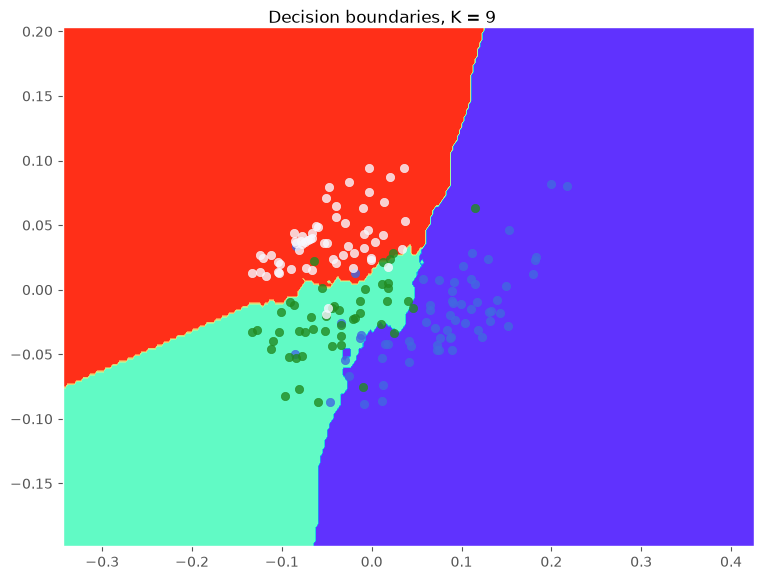

In [13]:
myColours = ['royalblue', 'forestgreen', 'ghostwhite']

plotDecisionBoundary(knn, X_train_pca, y_train, colors=myColours)


In [14]:
# Accuracy of the KNN model on the test set
# (.score() runs prediction internally, no need to call .predict() first)
print(knn.score(X_test_pca, y_test))


0.9047619047619048


In [15]:
# Load the breast cancer dataset, set headers, and mark '?' as NaN
X = pd.read_csv("breast-cancer-wisconsin.data", header=None,
                 names=['sample', 'thickness', 'size', 'shape', 'adhesion',
                        'epithelial', 'nuclei', 'chromatin', 'nucleoli',
                        'mitoses', 'status'], index_col='sample', na_values='?')


In [16]:
X.head()


,thickness,size,shape,adhesion,epithelial,nuclei,chromatin,nucleoli,mitoses,status
sample,,,,,,,,,,
1000025,5,1,1,1,2,1.0,3,1,1,2
1002945,5,4,4,5,7,10.0,3,2,1,2
1015425,3,1,1,1,2,2.0,3,1,1,2
1016277,6,8,8,1,3,4.0,3,7,1,2
1017023,4,1,1,3,2,1.0,3,1,1,2


In [17]:
# Extract the target column, then drop it from the feature set
y = X.status.copy()
X.drop(['status'], axis=1, inplace=True)

# Fill any missing values with the column mean
if X.isnull().values.any():
    print("Preprocessing data: substituted all NaN with mean value")
    X.fillna(X.mean(), inplace=True)
else:
    print("Preprocessing data: No NaN found!")


Preprocessing data: substituted all NaN with mean value


In [18]:
# Split into training/testing sets (80/20), fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                       test_size=0.2, random_state=7)


In [19]:
# Hyperparameter search space
reducers = [False, True]  # False = Isomap, True = PCA
weights = ['uniform', 'distance']

# Features are in mixed units, so try several scalers
scalers = [preprocessing.Normalizer, preprocessing.StandardScaler,
           preprocessing.MinMaxScaler, preprocessing.RobustScaler]

from sklearn.decomposition import PCA
from sklearn import manifold


In [20]:
separator = "--------------------------------------"
print('*** Starting K-neighbours classifier')
print(separator)

bestScore = 0.0

# Outer loop: try each scaler
for scaler in scalers:
    print("* Scaler = ", scaler)
    scalerTrained = scaler().fit(X_train)
    X_train_scaled = scalerTrained.transform(X_train)
    X_test_scaled = scalerTrained.transform(X_test)

    print("PCA? | K | Weight | Score")
    print(separator)

    # Middle loop: try PCA vs. Isomap for dimensionality reduction
    reducer = None
    for isPCA in reducers:
        if isPCA:
            reducer = PCA(n_components=2).fit(X_train_scaled)
        else:
            reducer = manifold.Isomap(n_neighbors=10, n_components=2).fit(X_train_scaled)

        # Project both train and test sets into 2D
        X_train_reduced = reducer.transform(X_train_scaled)
        X_test_reduced = reducer.transform(X_test_scaled)

        # Inner loop: try K from 1-15 and both weighting schemes
        for k in range(1, 16):
            for weight in weights:
                knmodel = KNeighborsClassifier(n_neighbors=k, weights=weight)
                knmodel.fit(X_train_reduced, y_train)

                # NOTE: in a real medical setting it's far more costly to misclassify
                # a malignant tumor as benign than the reverse -- worth revisiting
                # with class weighting if this were a production model.

                currentScore = knmodel.score(X_test_reduced, y_test)
                print(f"{isPCA} | {k} | {weight} | {currentScore}")

                # Track the best-performing combination
                if currentScore > bestScore:
                    bestScore = currentScore
                    bestPCA = isPCA
                    bestK = k
                    bestWeight = weight
                    bestScaler = scaler


*** Starting K-neighbours classifier
--------------------------------------
* Scaler =  <class 'sklearn.preprocessing._data.Normalizer'>
PCA? | K | Weight | Score
--------------------------------------
False | 1 | uniform | 0.85
False | 1 | distance | 0.85
False | 2 | uniform | 0.7642857142857142
False | 2 | distance | 0.85
False | 3 | uniform | 0.85
False | 3 | distance | 0.8642857142857143
False | 4 | uniform | 0.8428571428571429
False | 4 | distance | 0.8642857142857143
False | 5 | uniform | 0.8571428571428571
False | 5 | distance | 0.8714285714285714
False | 6 | uniform | 0.8642857142857143
False | 6 | distance | 0.8642857142857143
False | 7 | uniform | 0.8571428571428571
False | 7 | distance | 0.8714285714285714
False | 8 | uniform | 0.8642857142857143
False | 8 | distance | 0.8714285714285714
False | 9 | uniform | 0.8642857142857143
False | 9 | distance | 0.8785714285714286
False | 10 | uniform | 0.8785714285714286
False | 10 | distance | 0.8785714285714286
False | 11 | uniform |

In [21]:
print("These are the best parameters for the model:")
print("PCA? | K | Weight | Scaler | Score")
print(f"{bestPCA} | {bestK} | {bestWeight} | {bestScaler} | {bestScore}")


These are the best parameters for the model:
PCA? | K | Weight | Scaler | Score
True | 5 | uniform | <class 'sklearn.preprocessing._data.StandardScaler'> | 0.9642857142857143


In [22]:
BestScalerTrained = bestScaler().fit(X_train)
X_train_scaled = BestScalerTrained.transform(X_train)
X_test_scaled = BestScalerTrained.transform(X_test)

# Re-apply the best reducer found during the search
if isPCA:
    reducer = PCA(n_components=2).fit(X_train_scaled)
else:
    reducer = manifold.Isomap(n_neighbors=10, n_components=2).fit(X_train_scaled)

X_train_reduced = reducer.transform(X_train_scaled)
X_test_reduced = reducer.transform(X_test_scaled)

# Train the final model using the best hyperparameters found
bestKnmodel = KNeighborsClassifier(n_neighbors=bestK, weights=bestWeight)
bestKnmodel.fit(X_train_reduced, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[2,4]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


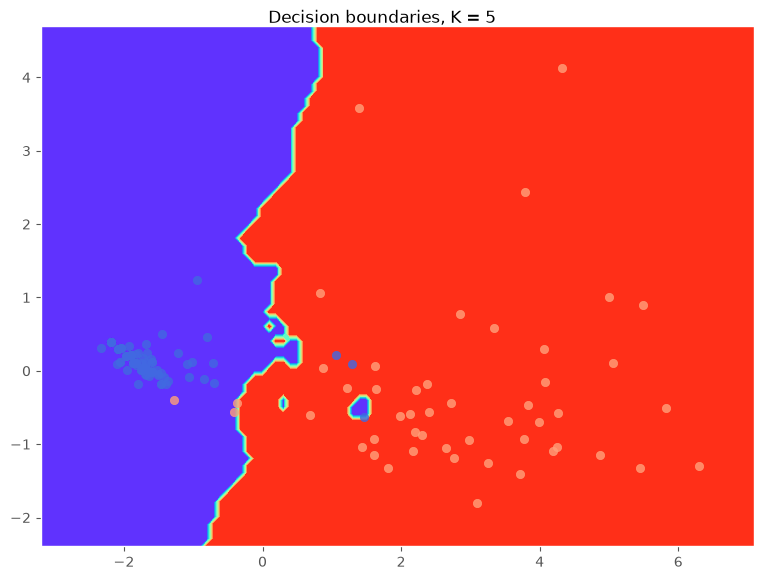

In [23]:
# 2 = benign (blue), 4 = malignant (red)
myColours = {2: 'royalblue', 4: 'lightsalmon'}

plotDecisionBoundary(bestKnmodel, X_test_reduced, y_test, colors=myColours, padding=0.1, resolution=0.1)
